# Respostas — Atividade Avaliativa II
**Componente Curricular:** Fundamentos do Processamento Digital de Imagens  
**Professor:** Fabricio Bizotto  

Este notebook contém as respostas e a execução dos algoritmos em OpenCV e Matplotlib para as 9 questões da Atividade Avaliativa II.

## Questão 1 (1 ponto)
**Carregue uma imagem RGB qualquer. Converta e mostre a imagem no padrão RGB, escala de cinza e HSL.**

### Explicação:
O OpenCV lê imagens no formato **BGR**. Para manipulá-las e exibi-las corretamente no Matplotlib:
- **RGB:** Convertido com `cv2.COLOR_BGR2RGB`.
- **Escala de Cinza:** Convertido com `cv2.COLOR_BGR2GRAY`.
- **HSL:** Representado como **HLS** no OpenCV, convertido com `cv2.COLOR_BGR2HLS`.

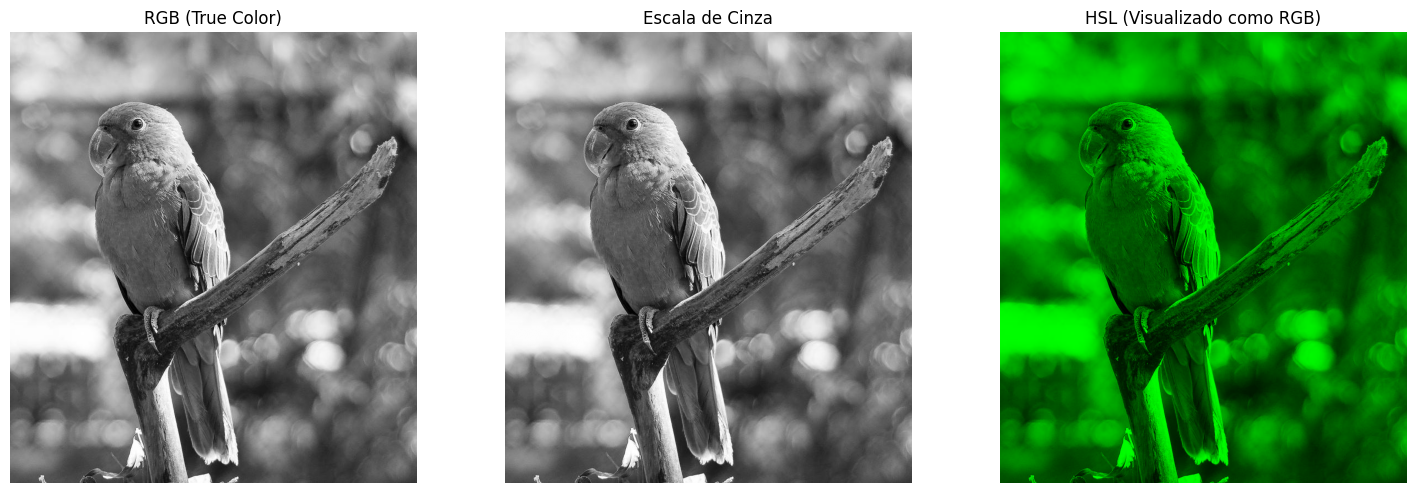

In [1]:
import cv2
import matplotlib.pyplot as plt

# Carrega imagem original
img1_bgr = cv2.imread("data/input/parrot.jpeg")

# Conversões de cor
img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
img1_hsl = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2HLS)

# Exibição
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img1_rgb)
axes[0].set_title("RGB (True Color)")
axes[0].axis("off")

axes[1].imshow(img1_gray, cmap="gray")
axes[1].set_title("Escala de Cinza")
axes[1].axis("off")

axes[2].imshow(img1_hsl)
axes[2].set_title("HSL (Visualizado como RGB)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Questão 2 (1 ponto)
**Melhore o contraste da imagem pout.tiff. Mostre a imagem original e a imagem melhorada. Mostre também o histograma original e o histograma da imagem melhorada.**

### Explicação:
A imagem de entrada possui baixo contraste dinâmico. Comparamos duas técnicas:
1. **Equalização Global de Histograma (`cv2.equalizeHist`):** Estica de forma global a faixa dinâmica de tons, mas pode amplificar ruídos em áreas uniformes.
2. **CLAHE (Equalização de Histograma Adaptativa Limitada por Contraste):** Limita localmente a amplificação de contraste em sub-blocos da imagem, mantendo tons mais suaves e naturais.

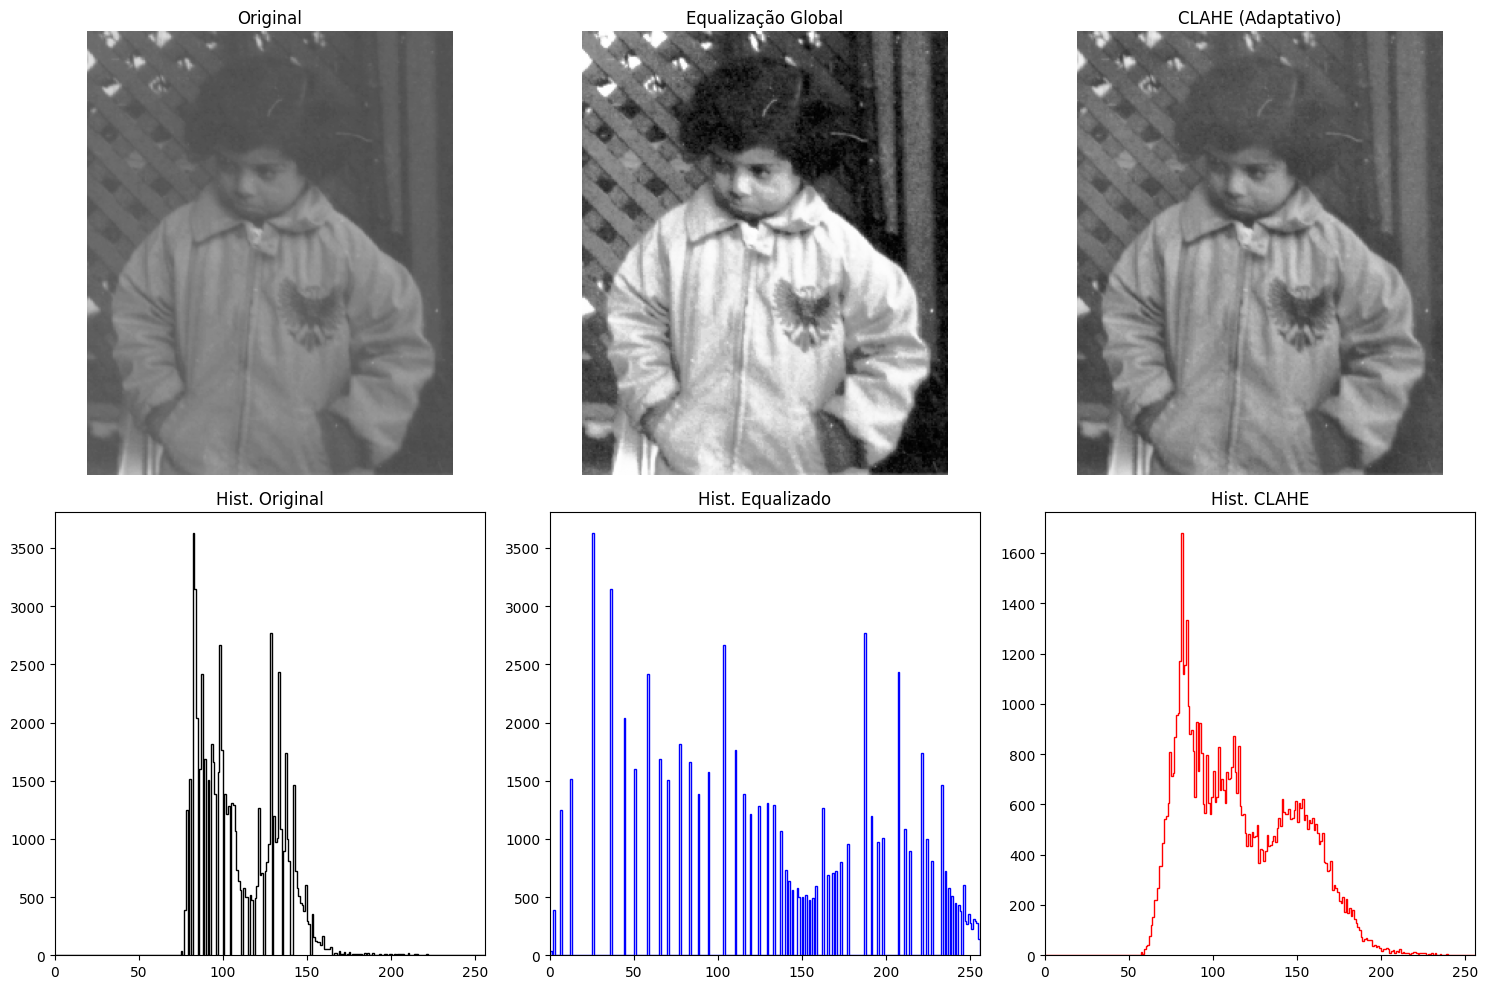

In [2]:
img2 = cv2.imread("data/input/pout.tif", cv2.IMREAD_GRAYSCALE)

# Equalização Global
img2_eq = cv2.equalizeHist(img2)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img2_clahe = clahe.apply(img2)

# Geração dos gráficos
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(img2_eq, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Equalização Global")
axes[0, 1].axis('off')

axes[0, 2].imshow(img2_clahe, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("CLAHE (Adaptativo)")
axes[0, 2].axis("off")

axes[1, 0].hist(img2.ravel(), bins=256, range=[0, 256], color="black", histtype="step")
axes[1, 0].set_title("Hist. Original")
axes[1, 0].set_xlim([0, 256])

axes[1, 1].hist(img2_eq.ravel(), bins=256, range=[0, 256], color="blue", histtype="step")
axes[1, 1].set_title("Hist. Equalizado")
axes[1, 1].set_xlim([0, 256])

axes[1, 2].hist(img2_clahe.ravel(), bins=256, range=[0, 256], color="red", histtype='step')
axes[1, 2].set_title("Hist. CLAHE")
axes[1, 2].set_xlim([0, 256])

plt.tight_layout()
plt.show()

## Questão 3 (1 ponto)
**Normalize o histograma da imagem ifc_vda.jpeg. Mostrar a imagem e o histograma original e resultante.**

### Explicação:
A normalização por Min-Max stretching (`cv2.normalize`) mapeia linearmente a faixa dinâmica original para abranger o espectro $[0, 255]$. Isso melhora a nitidez visual da imagem expandindo horizontalmente o histograma, sem alterar o formato geral de distribuição estatística.

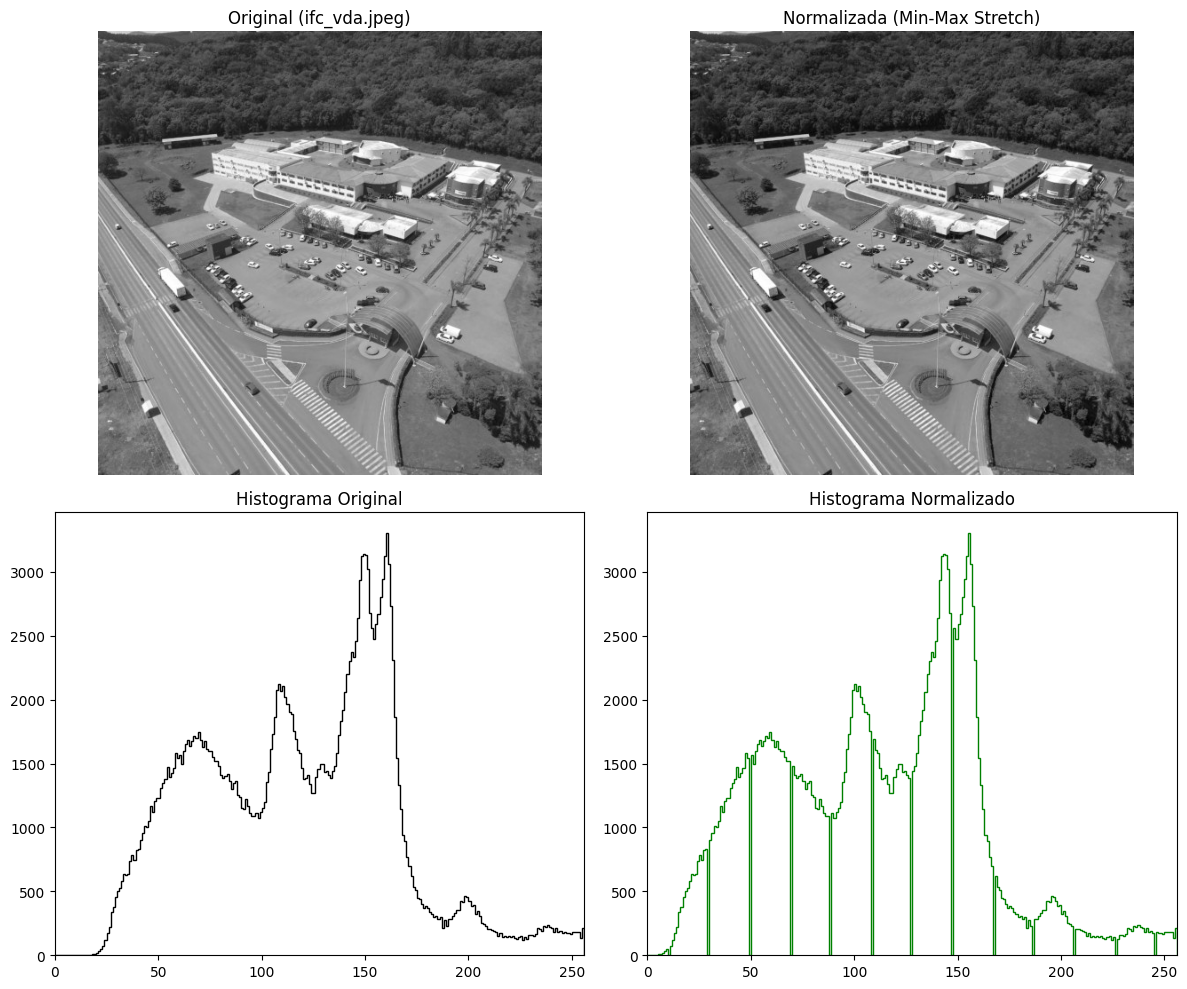

In [3]:
img3 = cv2.imread("data/input/ifc_vda.jpeg", cv2.IMREAD_GRAYSCALE)

# Normalização Min-Max
img3_norm = cv2.normalize(img3, None, 0, 255, cv2.NORM_MINMAX)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img3, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original (ifc_vda.jpeg)")
axes[0, 0].axis("off")

axes[0, 1].imshow(img3_norm, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Normalizada (Min-Max Stretch)")
axes[0, 1].axis("off")

axes[1, 0].hist(img3.ravel(), bins=256, range=[0, 256], color="black", histtype="step")
axes[1, 0].set_title("Histograma Original")
axes[1, 0].set_xlim([0, 256])

axes[1, 1].hist(img3_norm.ravel(), bins=256, range=[0, 256], color="green", histtype="step")
axes[1, 1].set_title("Histograma Normalizado")
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

## Questão 4 (1 ponto)
**Ler um arquivo de imagem em escala de cinza e exibir. Aplique o processamento linear de limiarização (thresholding) na imagem e mostre a imagem resultante. Ao final, apresentar o histograma da imagem de entrada e da imagem resultante.**

### Explicação:
A limiarização de valor fixo converte imagens em tons de cinza em representações binárias (preto e branco). O histograma resultante demonstra atividade concentrada apenas em dois níveis discretos: `0` (fundo) e `255` (caractere/objeto).

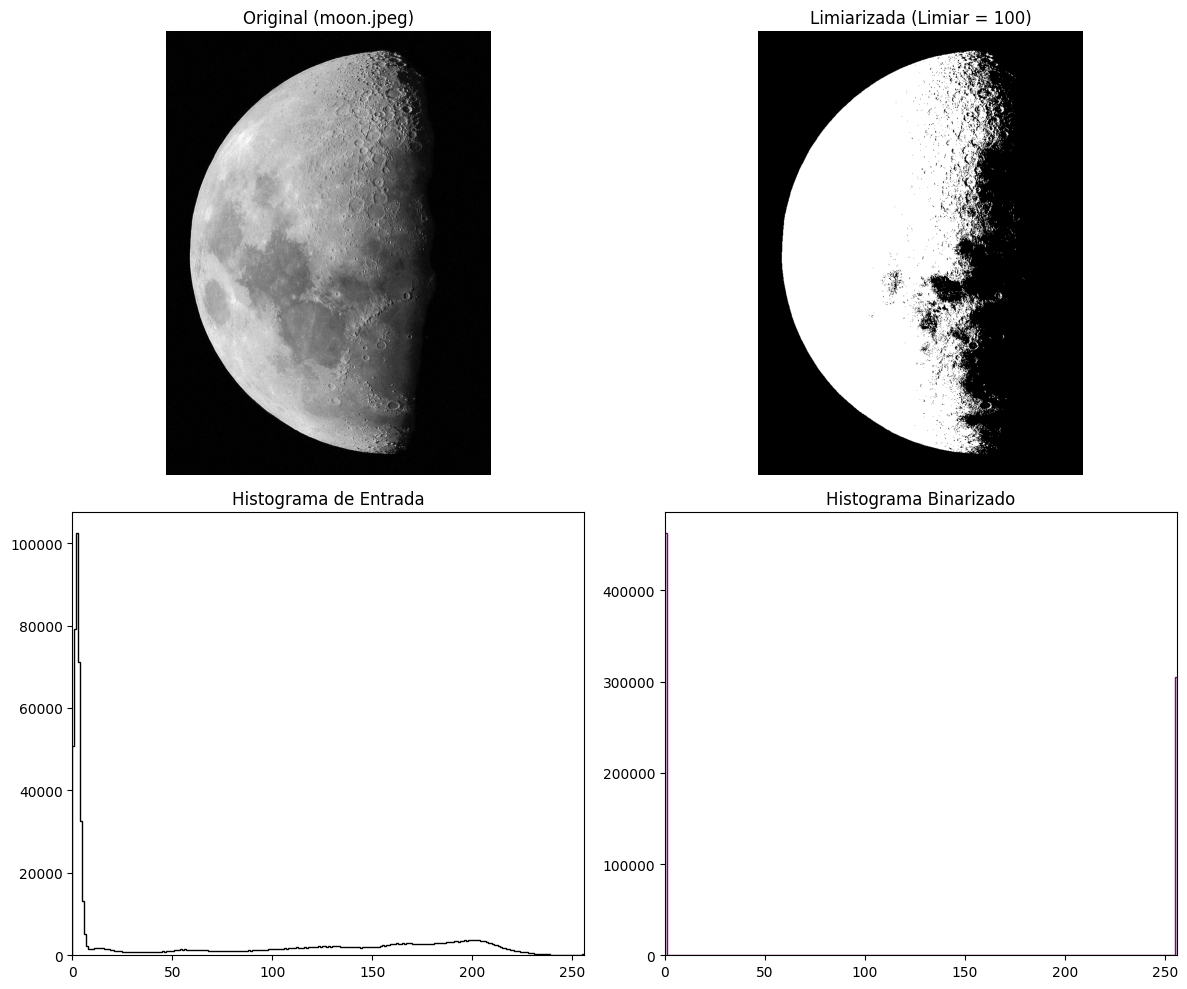

In [4]:
img4 = cv2.imread("data/input/moon.jpeg", cv2.IMREAD_GRAYSCALE)

# Limiarização linear em 100
thresh_val = 100
_, img4_bin = cv2.threshold(img4, thresh_val, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img4, cmap="gray")
axes[0, 0].set_title("Original (moon.jpeg)")
axes[0, 0].axis("off")

axes[0, 1].imshow(img4_bin, cmap="gray")
axes[0, 1].set_title(f"Limiarizada (Limiar = {thresh_val})")
axes[0, 1].axis("off")

axes[1, 0].hist(img4.ravel(), bins=256, range=[0, 256], color="black", histtype="step")
axes[1, 0].set_title("Histograma de Entrada")
axes[1, 0].set_xlim([0, 256])

axes[1, 1].hist(img4_bin.ravel(), bins=256, range=[0, 256], color="purple", histtype="step")
axes[1, 1].set_title("Histograma Binarizado")
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

## Questão 5 (1 ponto)
**Utilizando as imagens ifc_01.png e ifc_02.png, realiza a operação lógica AND. Mostre as imagens de entrada e a imagem resultante.**

### Explicação:
A operação lógica AND mescla bit a bit os pixels das duas máscaras. O pixel resultante é branco ($255$) apenas se o mesmo pixel for ativo nas duas imagens ao mesmo tempo.

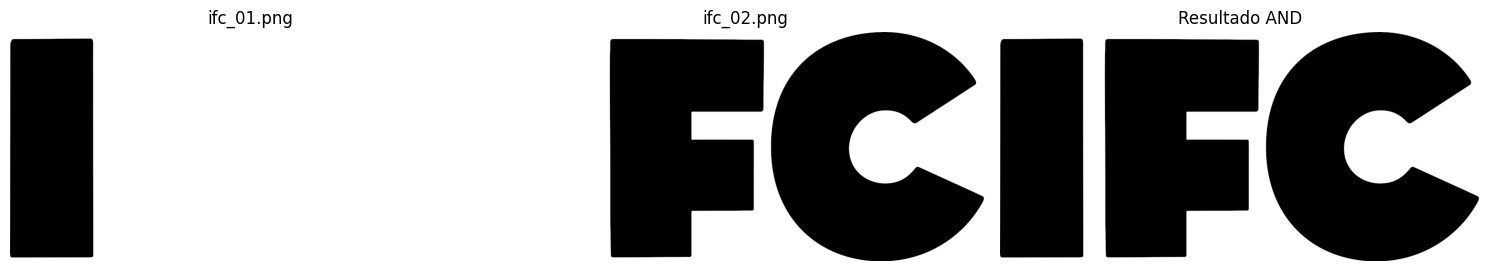

In [5]:
img5a = cv2.imread("data/input/ifc_01.png", cv2.IMREAD_GRAYSCALE)
img5b = cv2.imread("data/input/ifc_02.png", cv2.IMREAD_GRAYSCALE)

if img5a.shape != img5b.shape:
    img5b = cv2.resize(img5b, (img5a.shape[1], img5a.shape[0]))

img5_and = cv2.bitwise_and(img5a, img5b)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img5a, cmap="gray")
axes[0].set_title("ifc_01.png")
axes[0].axis("off")

axes[1].imshow(img5b, cmap="gray")
axes[1].set_title("ifc_02.png")
axes[1].axis("off")

axes[2].imshow(img5_and, cmap="gray")
axes[2].set_title("Resultado AND")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Questão 6 (1 ponto)
**Carregue as imagens mask1.png e mask2.png. Responda: as imagens são iguais? Calcule a diferença entre elas.**

### Resposta:
**Não**, as imagens `mask1.png` e `mask2.png` não são idênticas. Calculando a diferença absoluta matricial por meio de `cv2.absdiff`, encontramos **580 pixels divergentes**.

As imagens são idênticas? False
Número de pixels diferentes: 580


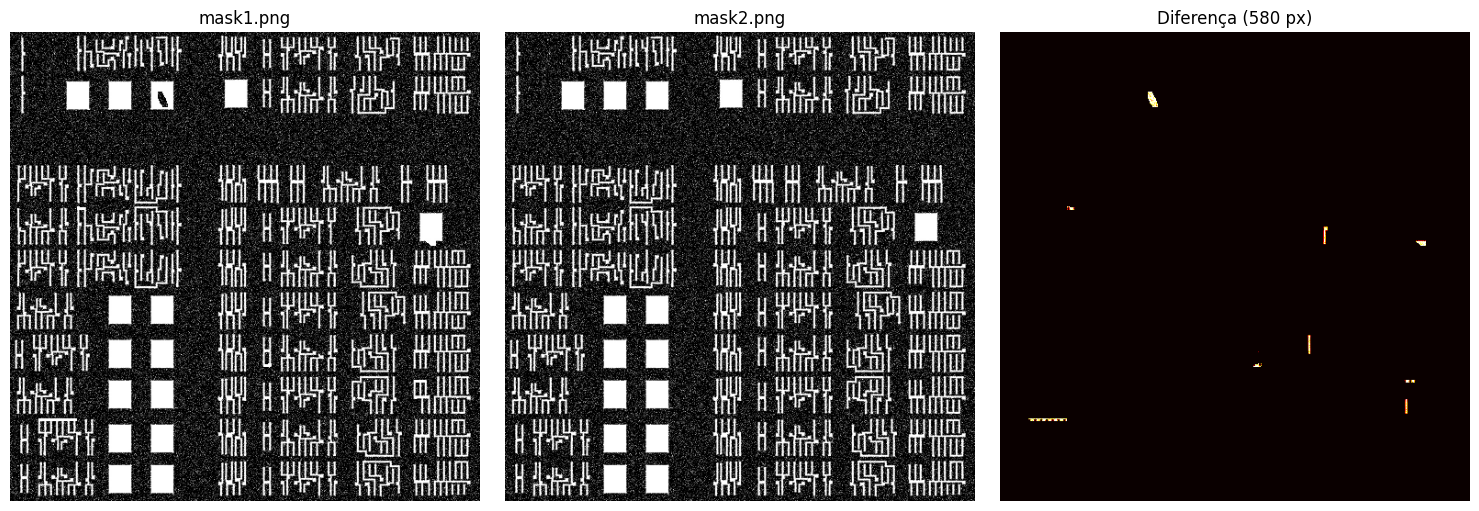

In [6]:
import numpy as np

img6a = cv2.imread("data/input/mask1.png", cv2.IMREAD_GRAYSCALE)
img6b = cv2.imread("data/input/mask2.png", cv2.IMREAD_GRAYSCALE)

are_equal = np.array_equal(img6a, img6b)
print(f"As imagens são idênticas? {are_equal}")

img6_diff = cv2.absdiff(img6a, img6b)
diff_count = np.sum(img6_diff > 0)
print(f"Número de pixels diferentes: {diff_count}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img6a, cmap="gray")
axes[0].set_title("mask1.png")
axes[0].axis("off")

axes[1].imshow(img6b, cmap="gray")
axes[1].set_title("mask2.png")
axes[1].axis("off")

axes[2].imshow(img6_diff, cmap="hot")
axes[2].set_title(f"Diferença ({diff_count} px)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Questão 7 (1 ponto)
**Utilize o filtro apropriado para eliminar o ruído da imagem hw3_license_plate_noisy.png.**

### Resposta:
A imagem possui ruído do tipo **sal e pimenta**. O filtro ideal para remoção desse tipo de ruído impulsivo é o **Filtro Mediano (`cv2.medianBlur`)**, pois ele substitui cada pixel pelo valor mediano da vizinhança. Como o ruído impulsivo assume valores extremos (0 ou 255), ele é filtrado com sucesso, preservando os contornos nítidos dos caracteres da placa.

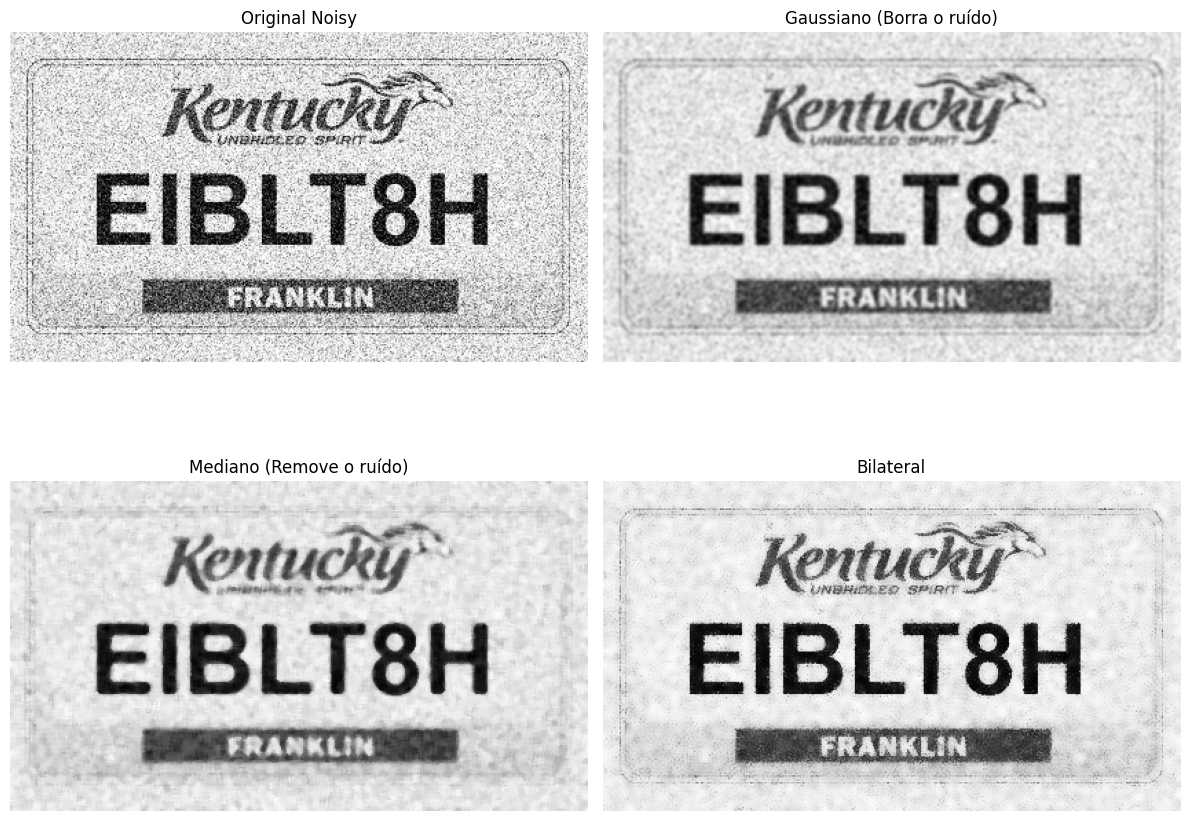

In [7]:
img7 = cv2.imread("data/input/hw3_license_plate_noisy.png", cv2.IMREAD_GRAYSCALE)

# Filtros comparativos
img7_gaussian = cv2.GaussianBlur(img7, (5, 5), 0)
img7_median = cv2.medianBlur(img7, 5)
img7_bilateral = cv2.bilateralFilter(img7, 9, 75, 75)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img7, cmap="gray")
axes[0, 0].set_title("Original Noisy")
axes[0, 0].axis("off")

axes[0, 1].imshow(img7_gaussian, cmap="gray")
axes[0, 1].set_title("Gaussiano (Borra o ruído)")
axes[0, 1].axis("off")

axes[1, 0].imshow(img7_median, cmap="gray")
axes[1, 0].set_title("Mediano (Remove o ruído)")
axes[1, 0].axis("off")

axes[1, 1].imshow(img7_bilateral, cmap="gray")
axes[1, 1].set_title("Bilateral")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Questão 8 (1 ponto)
**O objetivo dessa tarefa é limpar o ruído da imagem placa.png para pré-processamento de OCR.**

### Discussão das Operações Morfológicas:
- **Binarização por Otsu:** Encontra o limiar ideal dividindo as modas do histograma de brilho.
- **Abertura:** Remove ruídos pequenos (pontos brancos) fora da área dos caracteres.
- **Fechamento:** Preenche pequenos furos e falhas nos traços internos dos caracteres, consolidando sua forma.

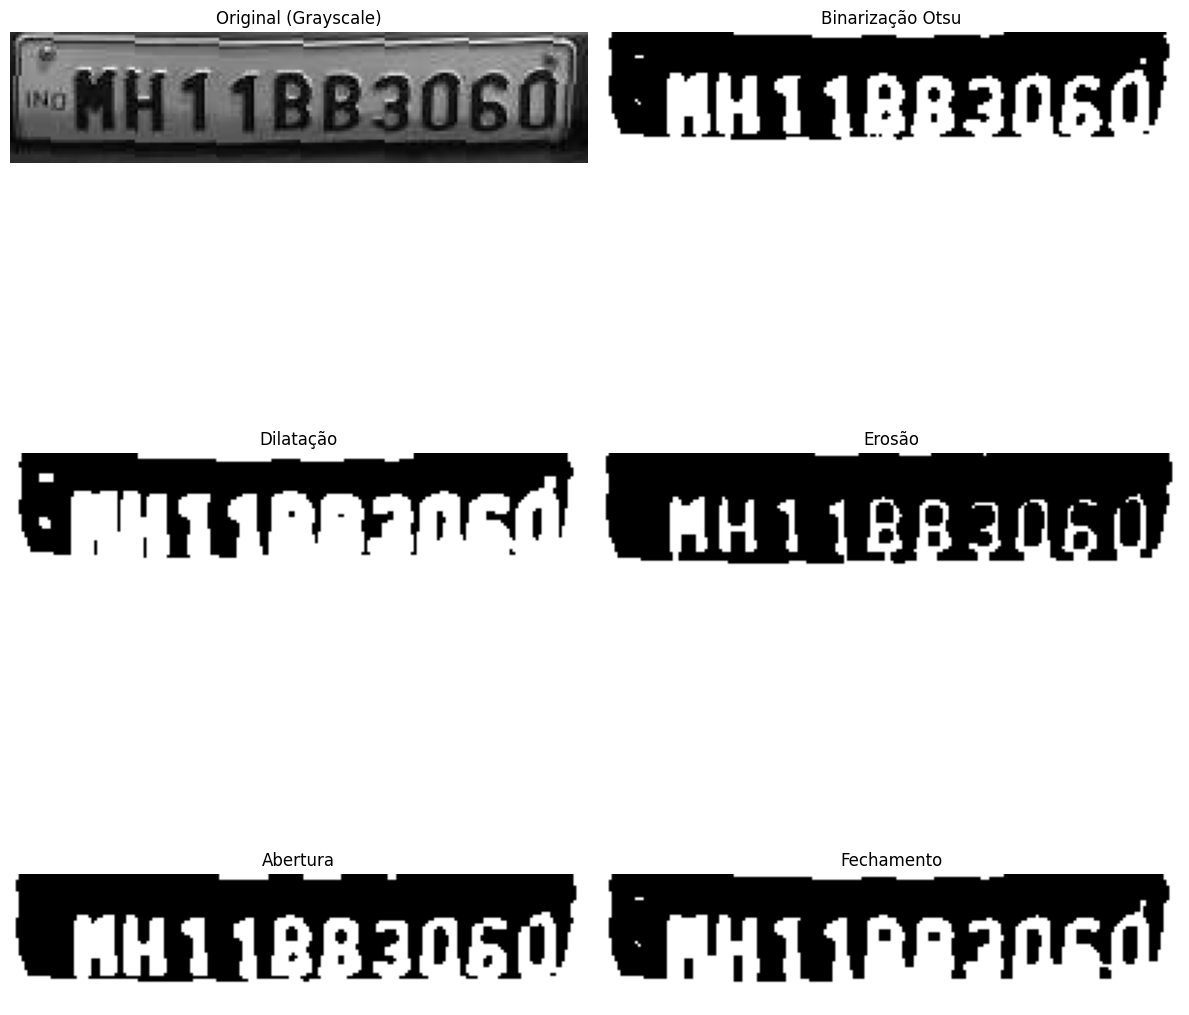

In [8]:
img8_bgr = cv2.imread("data/input/placa.png")
img8_gray = cv2.cvtColor(img8_bgr, cv2.COLOR_BGR2GRAY)

# Filtro Gaussiano de suavização preventiva
img8_blur = cv2.GaussianBlur(img8_gray, (5, 5), 0)

# Binarização de Otsu Invertida (caracteres em branco para morfologia)
_, img8_thresh = cv2.threshold(img8_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Elemento estruturante retangular 3x3
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
img8_dil = cv2.dilate(img8_thresh, kernel, iterations=1)
img8_ero = cv2.erode(img8_thresh, kernel, iterations=1)
img8_open = cv2.morphologyEx(img8_thresh, cv2.MORPH_OPEN, kernel)
img8_close = cv2.morphologyEx(img8_thresh, cv2.MORPH_CLOSE, kernel)

# Plot
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes[0, 0].imshow(img8_gray, cmap="gray")
axes[0, 0].set_title("Original (Grayscale)")
axes[0, 0].axis("off")

axes[0, 1].imshow(img8_thresh, cmap="gray")
axes[0, 1].set_title("Binarização Otsu")
axes[0, 1].axis("off")

axes[1, 0].imshow(img8_dil, cmap="gray")
axes[1, 0].set_title("Dilatação")
axes[1, 0].axis("off")

axes[1, 1].imshow(img8_ero, cmap="gray")
axes[1, 1].set_title("Erosão")
axes[1, 1].axis("off")

axes[2, 0].imshow(img8_open, cmap="gray")
axes[2, 0].set_title("Abertura")
axes[2, 0].axis("off")

axes[2, 1].imshow(img8_close, cmap="gray")
axes[2, 1].set_title("Fechamento")
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

## Questão 9 (2 pontos)
**Cones de trânsito são montados para bloquear a pista. Desenhe um retângulo ao redor dos cones identificando-os na imagem hw2_cone.jpg.**

### Pipeline de Detecção:
1. **HSL Color Space:** Permite isolar os tons laranja de forma robusta a alterações de luz e brilho.
2. **Filtro de Saturação ($S \ge 100$):** Remove as árvores e galhos secos do plano de fundo.
3. **Filtro Geométrico de Razão de Aspecto ($w / h \le 0.60$):** Cones são delgados e verticais. Esse filtro isola os cones e remove falsos positivos nos corpos das pessoas.

Cones identificados: 4


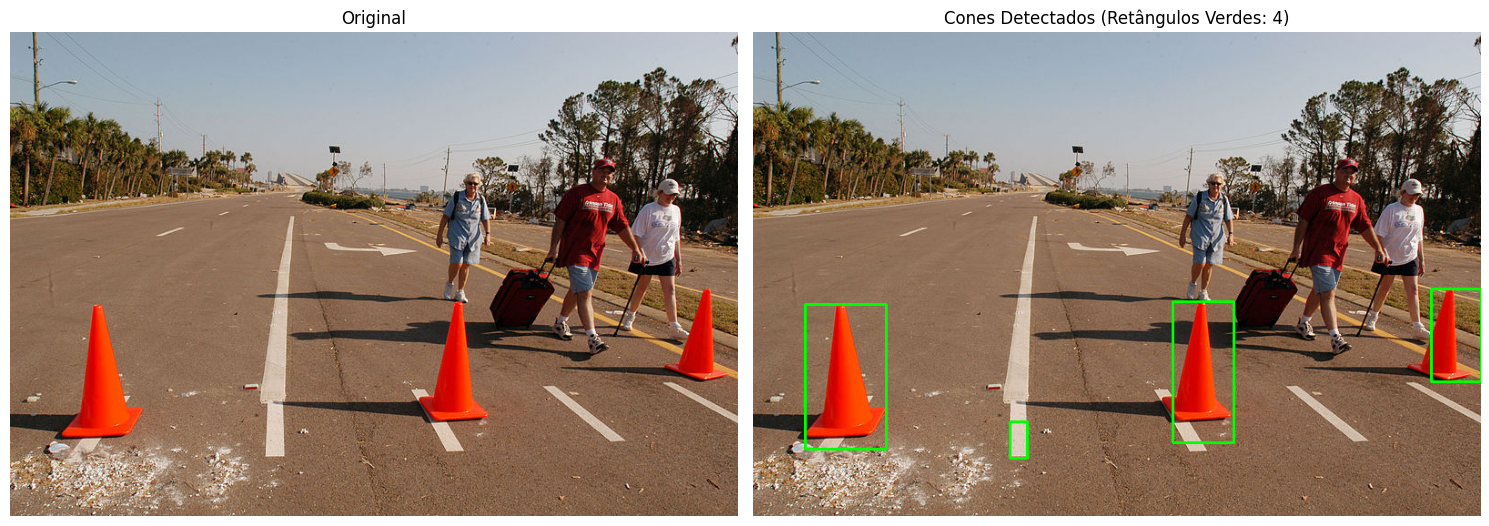

In [9]:
img9_bgr = cv2.imread("data/input/hw2_cone.jpg")
img9_rgb = cv2.cvtColor(img9_bgr, cv2.COLOR_BGR2RGB)
img9_hls = cv2.cvtColor(img9_bgr, cv2.COLOR_BGR2HLS)

# Limiares do tom laranja
lower_orange1 = np.array([3, 40, 100])
upper_orange1 = np.array([18, 220, 255])
lower_orange2 = np.array([170, 40, 100])
upper_orange2 = np.array([180, 220, 255])

mask = cv2.inRange(img9_hls, lower_orange1, upper_orange1) | cv2.inRange(img9_hls, lower_orange2, upper_orange2)

# Limpeza morfológica da máscara
kernel_cone = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_cone)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel_cone)

# Contornos
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img9_out = img9_rgb.copy()

cones_detected = 0
for c in contours:
    area = cv2.contourArea(c)
    if 100 < area < 10000:
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = float(w) / h
        if aspect_ratio <= 0.60 and y > 250:
            cv2.rectangle(img9_out, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cones_detected += 1

print(f"Cones identificados: {cones_detected}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].imshow(img9_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img9_out)
axes[1].set_title(f"Cones Detectados (Retângulos Verdes: {cones_detected})")
axes[1].axis("off")

plt.tight_layout()
plt.show()